# Car Price Prediction — Model Training

This notebook trains a regression model that predicts a used car's selling price
from features like year, present price, kilometers driven, fuel type, seller type,
transmission, and number of previous owners, using the **real Car Dekho used-car
dataset** (`car_data.csv` — 301 listings scraped from cardekho.com, a well-known
public dataset for this exact task).

At the end it exports:

- `model.pkl` — the trained model
- `columns.pkl` — the exact column order/encoding the model expects

Both files are picked up by the Flask app (`app.py`) that gets deployed on Render.

> Keep `car_data.csv` in the same folder as this notebook — if you move the notebook,
> bring the CSV with it, or update the path in the load cell below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

np.random.seed(42)
sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


## 1. Load the dataset

In [2]:
df = pd.read_csv('car_data.csv')
current_year = 2026   # used to compute Car_Age; bump this if you retrain in a later year

print(df.shape)
df.head()

(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## 2. Exploratory Data Analysis

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


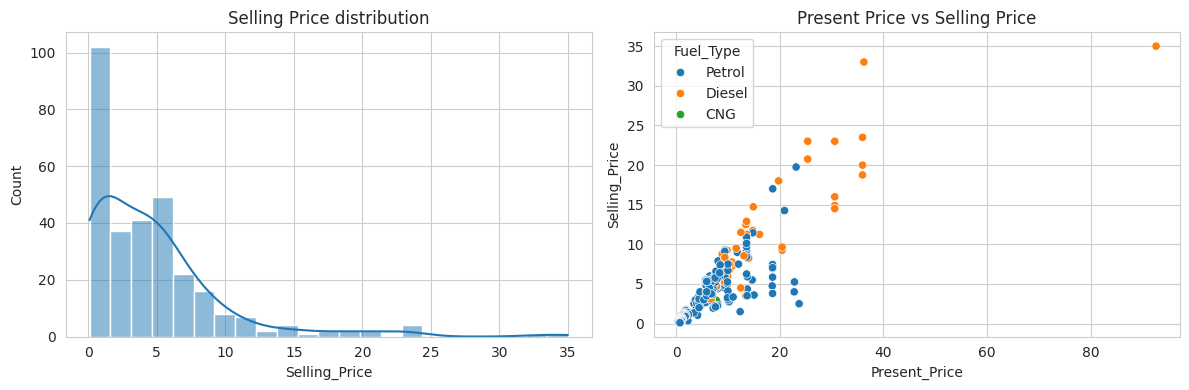

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0])
axes[0].set_title('Selling Price distribution')
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', ax=axes[1])
axes[1].set_title('Present Price vs Selling Price')
plt.tight_layout()
plt.show()

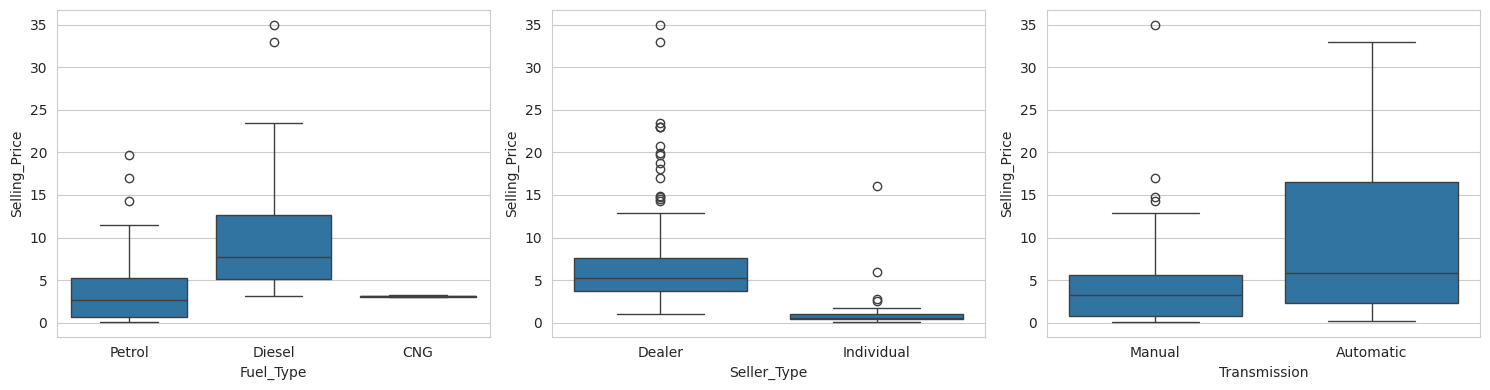

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0])
sns.boxplot(data=df, x='Seller_Type', y='Selling_Price', ax=axes[1])
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[2])
plt.tight_layout()
plt.show()

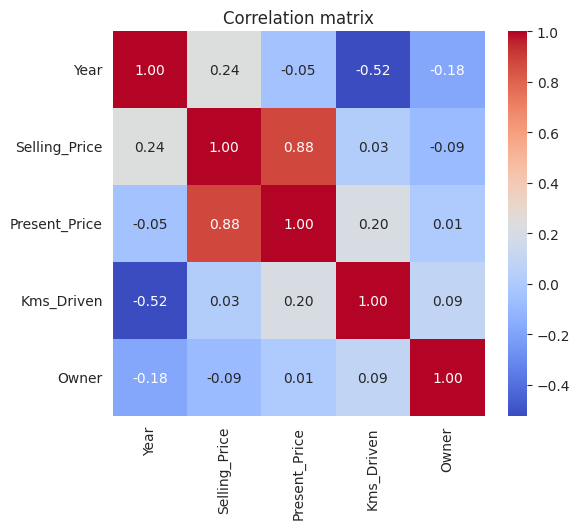

In [8]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

## 3. Feature engineering & encoding

- Drop `Car_Name` — with 301 rows and dozens of distinct car names, it's too
  high-cardinality to encode usefully without overfitting; `Present_Price` already
  captures most of what the car's make/model tells you about its price.
- Convert `Year` into `Car_Age` (more predictive, and stays valid in future years).
- Label-encode the categorical columns and **save the encoders** — the Flask app
  needs the exact same encoding at inference time.

In [9]:
df['Car_Age'] = current_year - df['Year']
df.drop(columns=['Year', 'Car_Name'], inplace=True)

categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,12
1,4.75,9.54,43000,1,0,1,0,13
2,7.25,9.85,6900,2,0,1,0,9
3,2.85,4.15,5200,2,0,1,0,15
4,4.60,6.87,42450,1,0,1,0,12


In [10]:
feature_cols = ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
                'Transmission', 'Owner', 'Car_Age']
X = df[feature_cols]
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(240, 7) (61, 7)


## 4. Train models and compare

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def report(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:16s}  R2={r2:.3f}   MAE={mae:.3f}   RMSE={rmse:.3f}")
    return r2

r2_lr = report("Linear Regression", y_test, lr_pred)
r2_rf = report("Random Forest", y_test, rf_pred)

Linear Regression  R2=0.847   MAE=1.222   RMSE=1.879
Random Forest     R2=0.960   MAE=0.633   RMSE=0.960


In [12]:
best_model = rf if r2_rf >= r2_lr else lr
best_name = "Random Forest" if best_model is rf else "Linear Regression"
print(f"Best model: {best_name}")

Best model: Random Forest


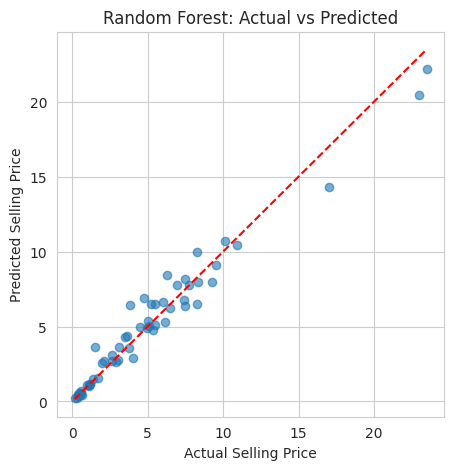

In [13]:
plt.figure(figsize=(5, 5))
best_pred = rf_pred if best_model is rf else lr_pred
plt.scatter(y_test, best_pred, alpha=0.6)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title(f'{best_name}: Actual vs Predicted')
plt.show()

## 5. Feature importance (Random Forest)

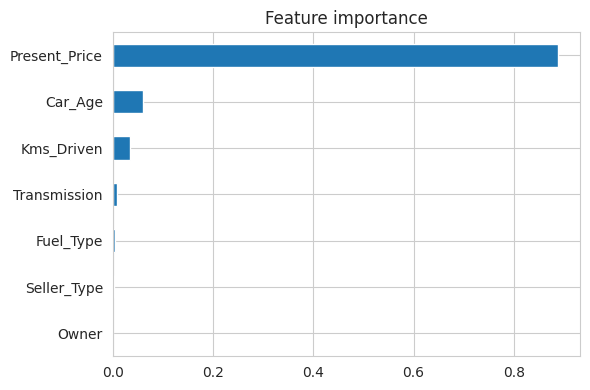

In [14]:
if best_model is rf:
    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
    importances.plot(kind='barh', figsize=(6, 4))
    plt.title('Feature importance')
    plt.tight_layout()
    plt.show()
else:
    print("Best model is Linear Regression — skipping RF importance plot.")

## 6. Export the model for deployment

Two files are saved:
- `model.pkl` — the trained regressor
- `columns.pkl` — a dict with the feature order + label encoders, so the Flask app
  can turn raw form input (e.g. `Fuel_Type = "Diesel"`) into the exact numeric
  encoding the model was trained on.

Copy both files into the deployment folder next to `app.py` before deploying.

In [15]:
joblib.dump(best_model, 'model.pkl')

deployment_meta = {
    'feature_cols': feature_cols,
    'encoders': encoders,          # dict of column -> fitted LabelEncoder
    'current_year_used_for_training': current_year,
    'model_name': best_name
}
joblib.dump(deployment_meta, 'columns.pkl')

print("Saved model.pkl and columns.pkl")

Saved model.pkl and columns.pkl


## 7. Sanity check — reload and predict once

In [16]:
loaded_model = joblib.load('model.pkl')
loaded_meta = joblib.load('columns.pkl')

sample = {
    'Present_Price': 9.5,
    'Kms_Driven': 40000,
    'Fuel_Type': 'Diesel',
    'Seller_Type': 'Dealer',
    'Transmission': 'Manual',
    'Owner': 0,
    'Car_Age': 5
}

row = []
for col in loaded_meta['feature_cols']:
    val = sample[col]
    if col in loaded_meta['encoders']:
        val = loaded_meta['encoders'][col].transform([val])[0]
    row.append(val)

pred = loaded_model.predict([row])[0]
print(f"Predicted selling price: {pred:.2f} lakhs")

Predicted selling price: 7.91 lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
